In [28]:
#say no to warnings!
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = '3'
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.backend import clear_session
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array,load_img
from tensorflow.keras.applications import resnet50, ResNet50

clear_session()

# Food or No Food

In this exercise we will train a Convolutional Neural Network in order to determine if a given image contains food or not.

The goal is to use Transfer Learning technique: 

the base model used for feature extraction is ResNet50, then to demonstrate how the heavylifting in CNNs is actually done by this first part of the Network we will train a simple Logistic Regression from the feature vectors extracted by the Convolutional section of the Network.

We are using a dataset downloaded from [here](https://drive.google.com/file/d/1De8Vg-EhPCc39_EKFca81kQnkM6i3S8z/view).

## Preprocessing

We are going to use Data Augmentation with ``` ImageDataGenerator``` and the appropriate ``` resnet50 ``` preprocessing function for both the training and testing split of the dataset.

In [15]:
train_datagen = ImageDataGenerator(preprocessing_function=resnet50.preprocess_input)

train_generator = train_datagen.flow_from_directory(
    'food_or_not/training/',
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=3000,
    class_mode='binary',
    shuffle=True
)

X_train, y_train = next(train_generator)

Found 3000 images belonging to 2 classes.


In [16]:
test_datagen = ImageDataGenerator(preprocessing_function=resnet50.preprocess_input)

test_generator = test_datagen.flow_from_directory(
    'food_or_not/testing/',
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=1000,
    class_mode='binary',
    shuffle=False
)

X_test, y_test = next(test_generator)

Found 1000 images belonging to 2 classes.


## Feature Extraction

Now let's download the pre-trained weights of the ResNet50 model:

In [17]:
# include_top = False allows to truncate the last section of the network
base_model = ResNet50(weights='imagenet', include_top=False)

We use those to extract features from our data:

In [18]:
# Build a feature extractor model
X = base_model.output
compact = GlobalAveragePooling2D()(X) # flatten the output tensor to a vector
feature_extractor = Model(
    inputs=base_model.input,
    outputs=compact
)

In [23]:
# Extract features for the full training set
X_train_feats = feature_extractor.predict(X_train)

94/94 ━━━━━━━━━━━━━━━━━━━━ 84s 879ms/step


In [24]:
# Extract features for test set
X_test_feats = feature_extractor.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 919ms/step


## Logistic Regression

Now it's time to train our LR:

In [25]:
# Train logistic regression on the feature vectors
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_feats, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
# Evaluate
print("Train accuracy: ", lr.score(X_train_feats, y_train))
print("Test accuracy: ", lr.score(X_test_feats, y_test))

Train accuracy:  1.0
Test accuracy:  0.986


## Results Visualization

In [96]:
def load_and_predict(path: str) -> str: 
    path = path if path is not None else 'food_or_not/testing/non_food/37.jpg'
    raw_img = load_img(path, target_size=(224, 224))
    np_img = np.expand_dims(img_to_array(raw_img), 0)
    preproc = resnet50.preprocess_input(np_img)
    feats = feature_extractor.predict(preproc)
    pred = lr.predict(feats)[0]
    return 'FOOD' if pred == 0 else 'NON FOOD'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


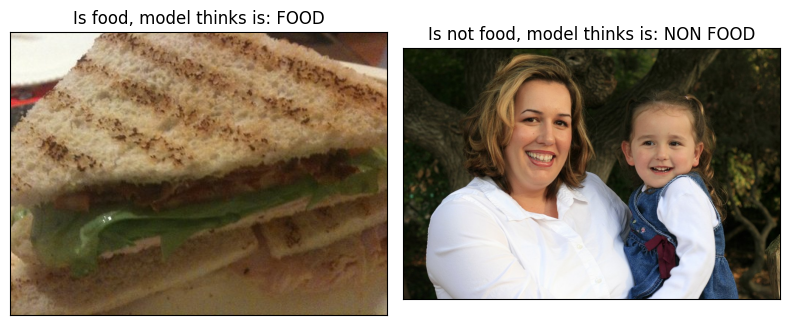

In [97]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
food_fname = np.random.choice(os.listdir('food_or_not/testing/food/'))
food_path = 'food_or_not/testing/food/' + food_fname
plt.imshow(load_img(food_path))
food_pred = load_and_predict(food_path)
plt.xticks([], [])
plt.yticks([], [])
plt.title('Is food, model thinks is: '+ food_pred)

plt.subplot(1, 2, 2)
non_food_fname = np.random.choice(os.listdir('food_or_not/testing/non_food/'))
non_food_path = 'food_or_not/testing/non_food/' + non_food_fname
plt.imshow(load_img(non_food_path))
nfood_pred = load_and_predict(non_food_path)
plt.xticks([], [])
plt.yticks([], [])
plt.title('Is not food, model thinks is: '+ nfood_pred)

plt.tight_layout();